In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data.loader import fetch_prices
from pairs.selection import find_pairs, compute_spread
from pairs.metrics import fit_ou
from signals.zscore import compute_zscore, generate_signals
from strategy.backtest import run_backtest, BacktestConfig
from analysis.performance import summarize

## Configuration
Edit this cell to change the universe, date range, or strategy parameters.

In [2]:
# --- Universe & dates ---
TICKERS = ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
START = '2010-01-01'
END   = '2024-12-31'

# --- Pair selection ---
P_THRESHOLD = 0.05
INSPECT_PAIR = None  # set to ('TICK1', 'TICK2') to override best pair

# --- Signal parameters ---
# ZSCORE_WINDOW is set automatically from the OU half-life below.
# Override it here with an integer (in days) if you want to experiment manually.
ZSCORE_WINDOW = None  # will be replaced by half-life unless you set it here
ENTRY_Z   = 2.0       # open trade when |z-score| crosses this level
EXIT_Z    = 0.0       # close trade when |z-score| falls below this level
STOP_Z    = 3.0       # emergency close if |z-score| exceeds this level

# --- Backtest parameters ---
COST_BPS = 5.0        # one-way transaction cost in basis points (5 bps = 0.05%)

## 1. Load Data and Select Pair

In [3]:
prices = fetch_prices(TICKERS, START, END)

pairs = find_pairs(prices, p_threshold=P_THRESHOLD)

if INSPECT_PAIR:
    t1, t2 = INSPECT_PAIR
    match = next((p for p in pairs if set(p['pair']) == {t1, t2}), None)
    hedge_ratio = match['hedge_ratio'] if match else 1.0
else:
    best = pairs[0]
    t1, t2 = best['pair']
    hedge_ratio = best['hedge_ratio']

# Fit the OU model to the spread to get the half-life
spread_raw = compute_spread(prices, t1, t2, hedge_ratio)
ou = fit_ou(spread_raw)

# Use the half-life as the z-score rolling window (unless manually overridden above)
if ZSCORE_WINDOW is None:
    ZSCORE_WINDOW = int(round(ou['half_life']))

print(f"Pair:        {t1}/{t2}")
print(f"Hedge ratio: {hedge_ratio:.4f}")
print(f"Half-life:   {ou['half_life']:.1f} days  ->  using ZSCORE_WINDOW = {ZSCORE_WINDOW}")
print(f"OU theta:    {ou['theta']:.4f}  (mean reversion speed per day)")
print(f"OU sigma:    {ou['sigma']:.4f}  (daily spread volatility)")
print(f"Valid pair:  {ou['is_valid']}")

Pair:        XLP/XLU
Hedge ratio: 2.1292
Half-life:   60.2 days  ->  using ZSCORE_WINDOW = 60
OU theta:    0.0115  (mean reversion speed per day)
OU sigma:    0.3927  (daily spread volatility)
Valid pair:  True


**What is a z-score signal?**
The z-score measures how far the current spread is from its historical average, in standard deviation units. A value above +2 means the gap is unusually wide; below -2 means it is unusually narrow. Those are the entry points. The position is closed when the z-score returns near 0.

**Signal values:**
- **+1**: long the spread. The gap was too narrow, so the cheap stock was bought and the expensive one sold short. The expectation is that the gap widens back toward its average.
- **-1**: short the spread. The gap was too wide, so the expensive stock was shorted and the cheap one bought. The expectation is that the gap closes.
- **0**: flat. No open position.

## 2. Compute Z-Score and Signals

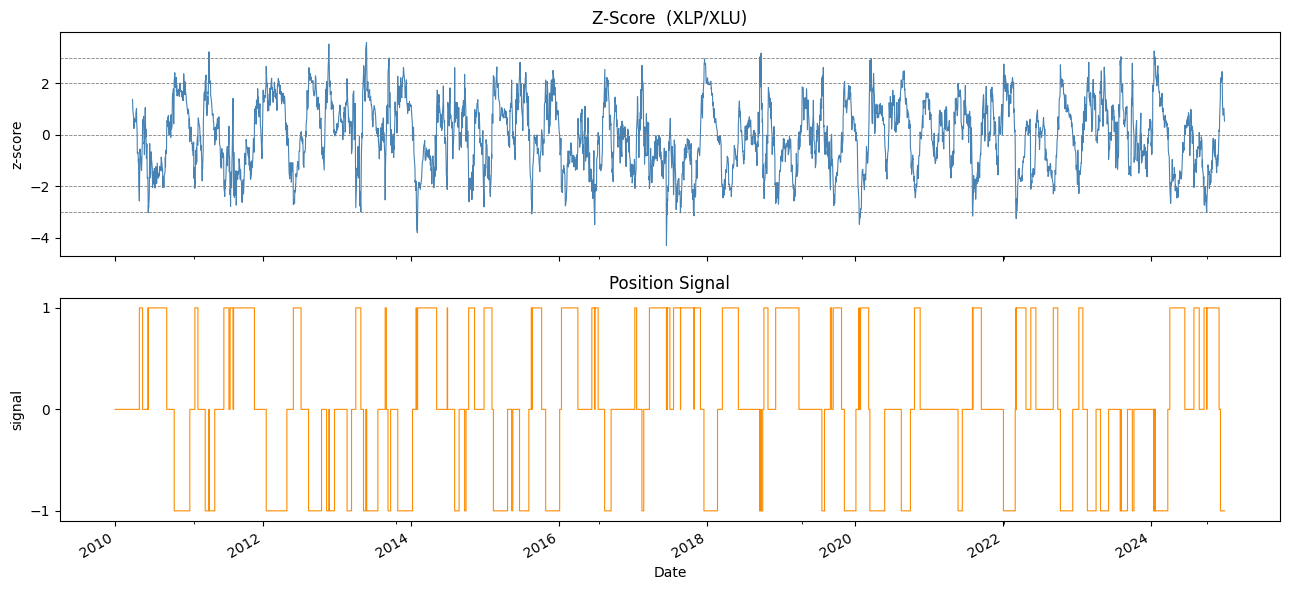

Days in market: 2033 / 3773  (53.9%)


In [4]:
spread  = compute_spread(prices, t1, t2, hedge_ratio)
zscore  = compute_zscore(spread, window=ZSCORE_WINDOW)
signals = generate_signals(zscore, entry=ENTRY_Z, exit=EXIT_Z, stop=STOP_Z)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

zscore.plot(ax=axes[0], color='steelblue', linewidth=0.8)
for level in [-STOP_Z, -ENTRY_Z, EXIT_Z, ENTRY_Z, STOP_Z]:
    axes[0].axhline(level, color='grey', linestyle='--', linewidth=0.6)
axes[0].set_title(f'Z-Score  ({t1}/{t2})')
axes[0].set_ylabel('z-score')

signals.plot(ax=axes[1], color='darkorange', linewidth=0.8, drawstyle='steps-post')
axes[1].set_title('Position Signal')
axes[1].set_ylabel('signal')
axes[1].set_yticks([-1, 0, 1])

plt.tight_layout()
plt.show()

print(f"Days in market: {(signals != 0).sum()} / {len(signals)}  ({100*(signals != 0).mean():.1f}%)")

> **Observations - Signals**
>
> The strategy is in a position 53.9% of trading days (2033 of 3773). That is high. For most of the period the strategy is almost always either long or short the spread, with short flat periods between trades.
>
> There are no long dead stretches. The z-score crosses ±2 regularly throughout the full 14-year window, so the signal fires consistently. The position panel confirms this: entries alternate between +1 and -1 with only brief gaps at 0.
>
> The signal tracks the z-score correctly. Entries appear when the z-score crosses ±2 and positions close when it returns toward 0. The logic looks right.
>
> One thing worth flagging: around 2020 the z-score dips to nearly -4, well past the stop-loss threshold of -3. That is the kind of extreme move that the stop is designed for. Whether the stop fired correctly and at what cost is something the performance summary below will show.

**What is a vectorized backtest?**
A backtest replays the strategy over historical data as if it had been traded in real time. "Vectorized" means all positions and PnL are computed at once using array operations rather than a day-by-day loop. It is fast and clean, but assumes orders fill at the closing price, a simplification that real execution will not always satisfy.

**Transaction costs:** every time a position opens or closes, there is friction from broker fees and the bid-ask spread. This is modeled as a fixed cost in basis points. One basis point is 0.01%, so 5 bps = 0.05% of the position value per trade. A full round trip (entry plus exit) costs 10 bps total.

## 3. Run Backtest

In [5]:
config = BacktestConfig(t1=t1, t2=t2, hedge_ratio=hedge_ratio, cost_bps=COST_BPS)
results = run_backtest(prices, signals, config=config)
results.tail()

,t1_ret,t2_ret,position,gross_pnl,trade,cost,net_pnl,equity
Date,,,,,,,,
2024-12-23,-0.005269,0.003404,-1,0.008726,False,0.0,0.008726,0.818963
2024-12-24,0.006589,0.005522,-1,-0.000930,False,0.0,-0.000930,0.818033
2024-12-26,0.003147,-0.002354,-1,-0.005556,False,0.0,-0.005556,0.812476
2024-12-27,-0.004894,-0.002883,-1,0.001958,False,0.0,0.001958,0.814435
2024-12-30,-0.011728,-0.004206,-1,0.007437,False,0.0,0.007437,0.821872


**What is the Sharpe ratio?**
Annualized return divided by annualized return volatility. It measures return per unit of risk. Above 1.0 is generally considered good; above 2.0 is excellent. Below 0 means average returns were negative.

**What is max drawdown?**
The largest peak-to-trough loss over the period. If the equity curve reached +10% then fell to +4%, the drawdown at that point was -6%. Max drawdown is the worst such episode. Less negative is better.

**What is win rate?**
The fraction of completed trades that closed profitably. Above 50% is consistent with a mean-reversion strategy. Win rate alone does not determine profitability; the average magnitude of wins relative to losses matters equally.

## 4. Performance Summary

In [6]:
stats = summarize(results)
for k, v in stats.items():
    print(f"{k:<22} {v}")

total_return           0.8219
annualized_return      0.0549
sharpe_ratio           0.593
max_drawdown           -0.2035
num_trades             171
win_rate               0.628
avg_trade_pnl          0.010051


## 5. Equity Curve and Drawdown

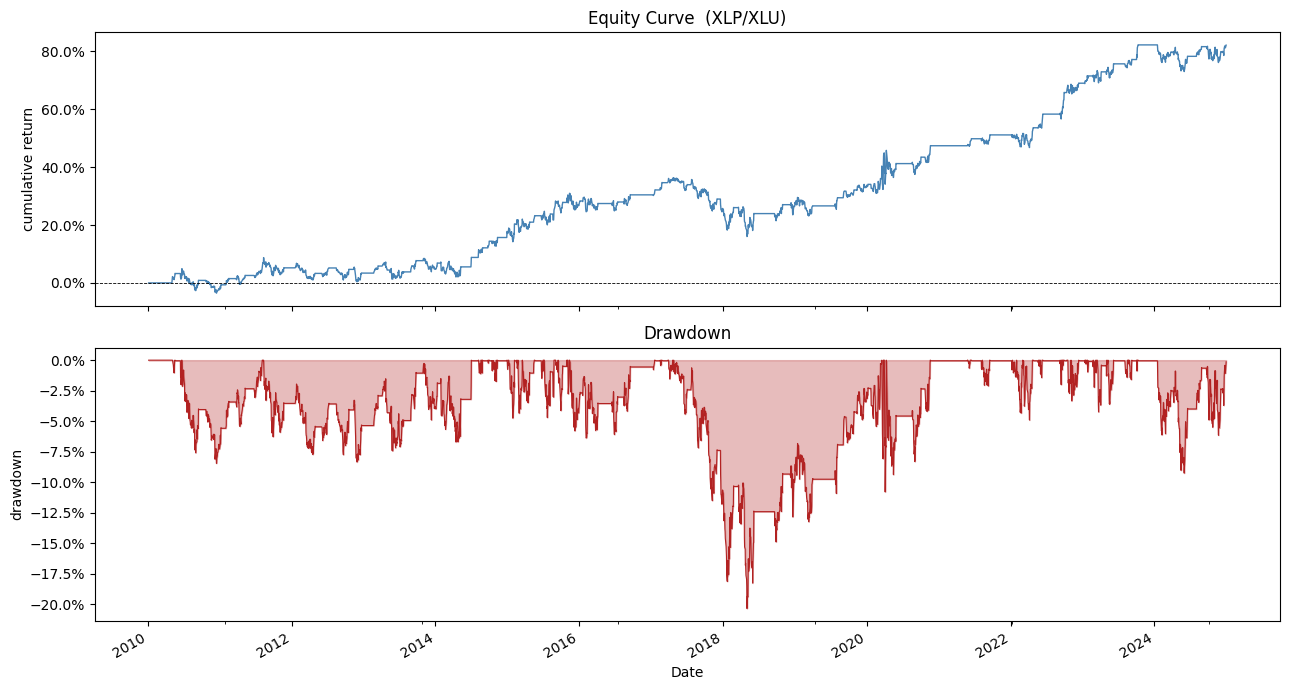

In [7]:
equity = results['equity']
drawdown = equity - equity.cummax()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

equity.plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].axhline(0, color='k', linewidth=0.6, linestyle='--')
axes[0].set_title(f'Equity Curve  ({t1}/{t2})')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

drawdown.plot(ax=axes[1], color='firebrick', linewidth=0.8)
axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.3, color='firebrick')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.show()

> **Observations - Results**
>
> The equity curve trends upward across the full period, ending at 82.2% cumulative return (5.5% annualised). Sharpe is 0.59 and win rate is 62.8% across 171 trades. Those are reasonable in-sample numbers for a first pass.
>
> The curve is not smooth. There are two distinct flat/sideways stretches: 2014-2016 and again around 2018. The worst period is the 2017-2018 drawdown, which reaches -20.4% (the deepest point in the drawdown chart). That is a large loss relative to the annualised return; it would take several years of average performance to recover from. The 2020 period shows some volatility but the strategy held up better there than in 2018.
>
> The Sharpe of 0.59 looks decent, but this is an in-sample result. The hedge ratio and z-score window were estimated on the same data the backtest trades on. The model has seen every price it is evaluated on. Notebook 05 will run the same strategy out-of-sample and show what happens to that number.
>
> Let's continue developing the tools to analyze this in the next few notebooks before adapting.